In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "income": np.random.randint(20000, 150000, n),
    "credit_score": np.random.randint(300, 850, n),
    "loan_amount": np.random.randint(5000, 100000, n),
    "debt_ratio": np.round(np.random.uniform(0.05, 0.80, n), 2),
    "employment_years": np.random.randint(0, 21, n)
})

data["approved"] = (
    (data["credit_score"] >= 650) &
    (data["income"] >= 40000) &
    (data["debt_ratio"] <= 0.50)
).astype(int)

noise = np.random.choice(n, size=80, replace=False)
data.loc[noise, "approved"] = 1 - data.loc[noise, "approved"]

print(data.head())
print("\nDataset shape:", data.shape)
print("\nApproval counts:")
print(data["approved"].value_counts())

   income  credit_score  loan_amount  debt_ratio  employment_years  approved
0  141958           760        37556        0.17                17         1
1   35795           846        83131        0.71                15         0
2   20860           552         6969        0.37                 9         0
3  123694           689        48753        0.17                17         1
4  148106           555        87811        0.06                 5         0

Dataset shape: (1000, 6)

Approval counts:
approved
0    778
1    222
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = data.drop("approved", axis=1)
y = data["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Training Accuracy:", round(model.score(X_train, y_train), 4))
print("Testing Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 0.9275
Testing Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       156
           1       0.89      0.57      0.69        44

    accuracy                           0.89       200
   macro avg       0.89      0.77      0.81       200
weighted avg       0.89      0.89      0.88       200



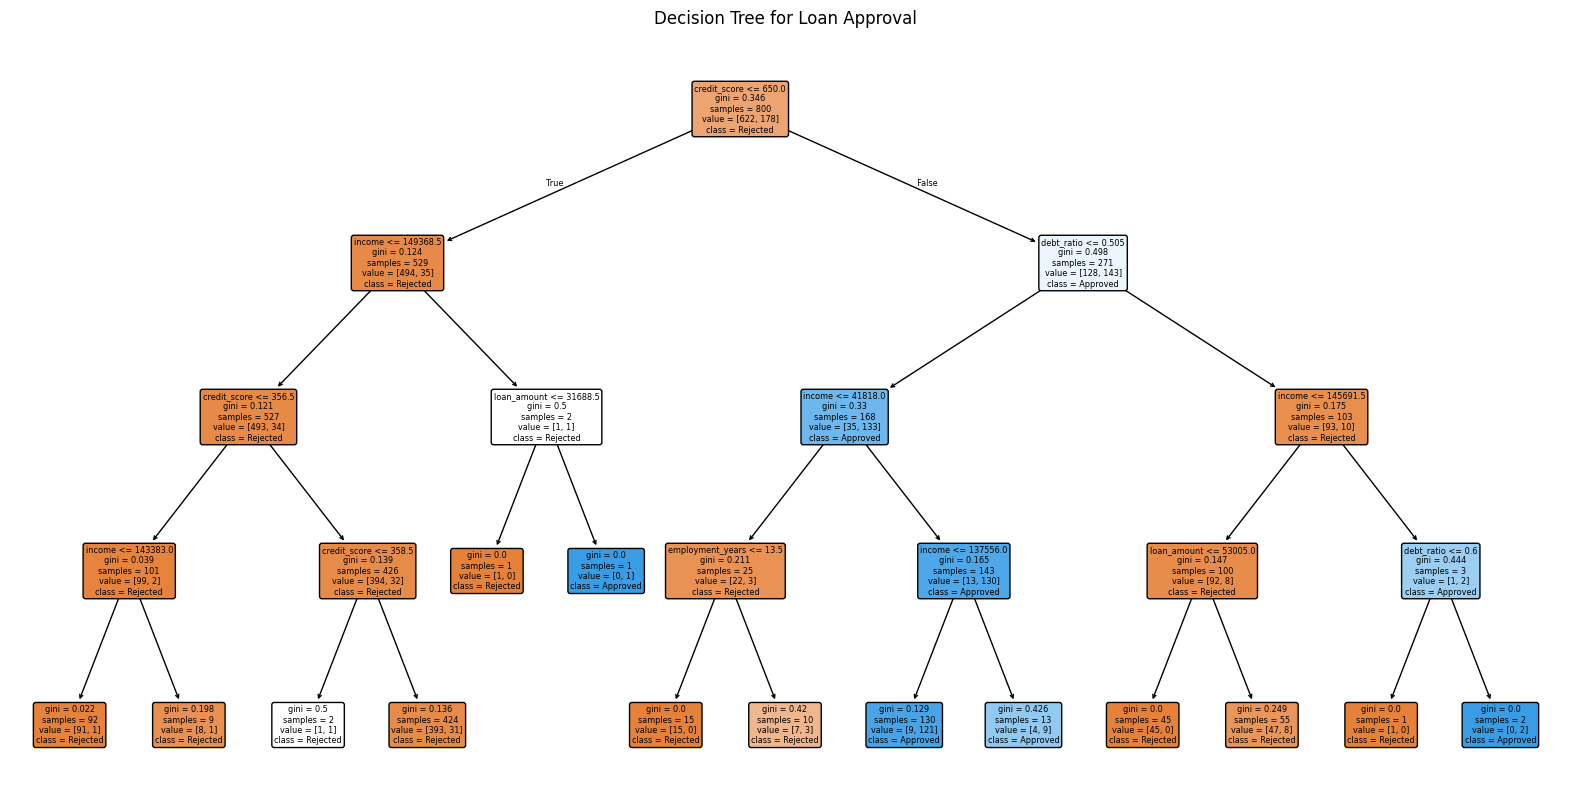

In [3]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Loan Approval")
plt.show()

            Feature  Importance
1      credit_score    0.444729
3        debt_ratio    0.360909
0            income    0.176430
2       loan_amount    0.011739
4  employment_years    0.006193


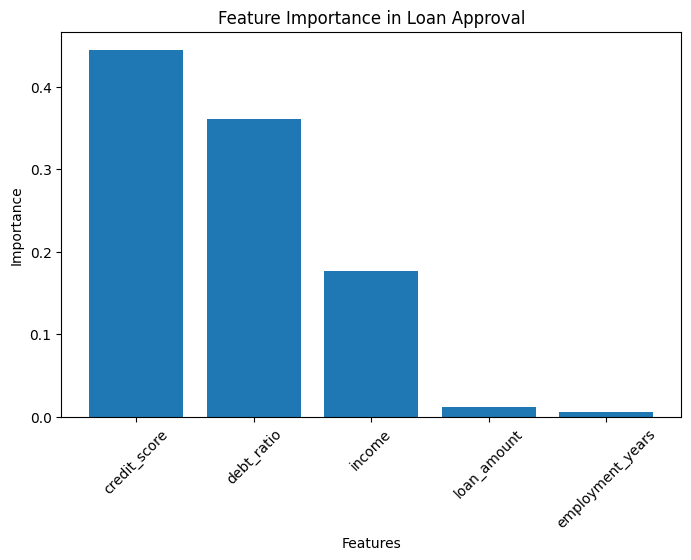

In [4]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.title("Feature Importance in Loan Approval")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [5]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Accuracy Difference:", round(train_accuracy - test_accuracy, 4))

if train_accuracy - test_accuracy > 0.05:
    print("\nPotential overfitting detected.")
else:
    print("\nNo major overfitting detected.")

Training Accuracy: 0.9275
Testing Accuracy: 0.89
Accuracy Difference: 0.0375

No major overfitting detected.


In [6]:
sample = X_test.iloc[0]

prediction = model.predict([sample])[0]

print("Sample Input:")
print(sample)

print("\nModel Decision:")
if prediction == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

print("\nDecision Path:")
node_indicator = model.decision_path([sample])
leaf_id = model.apply([sample])

node_index = node_indicator.indices[
    node_indicator.indptr[0]:node_indicator.indptr[1]
]

for node in node_index:
    if node == leaf_id[0]:
        continue

    feature = model.tree_.feature[node]
    threshold = model.tree_.threshold[node]

    print(
        f"{X.columns[feature]} <= {threshold:.2f}"
    )

Sample Input:
income              147948.00
credit_score           341.00
loan_amount           5661.00
debt_ratio               0.38
employment_years         2.00
Name: 251, dtype: float64

Model Decision:
Loan Rejected

Decision Path:
credit_score <= 650.00
income <= 149368.50
credit_score <= 356.50
income <= 143383.00


c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [7]:
feature_importance.to_csv(
    "day17_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [8]:
print("DAY 17 - LOAN APPROVAL USING DECISION TREE")
print("--------------------------------------------")
print("Dataset size:", data.shape)
print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Accuracy Difference:", round(train_accuracy - test_accuracy, 4))
print("Most Important Feature:", feature_importance.iloc[0]["Feature"])
print("Most Important Feature Score:",
      round(feature_importance.iloc[0]["Importance"], 4))
print("Overfitting:", "No major overfitting detected")
print("Model: Decision Tree Classifier")

DAY 17 - LOAN APPROVAL USING DECISION TREE
--------------------------------------------
Dataset size: (1000, 6)
Training Accuracy: 0.9275
Testing Accuracy: 0.89
Accuracy Difference: 0.0375
Most Important Feature: credit_score
Most Important Feature Score: 0.4447
Overfitting: No major overfitting detected
Model: Decision Tree Classifier
